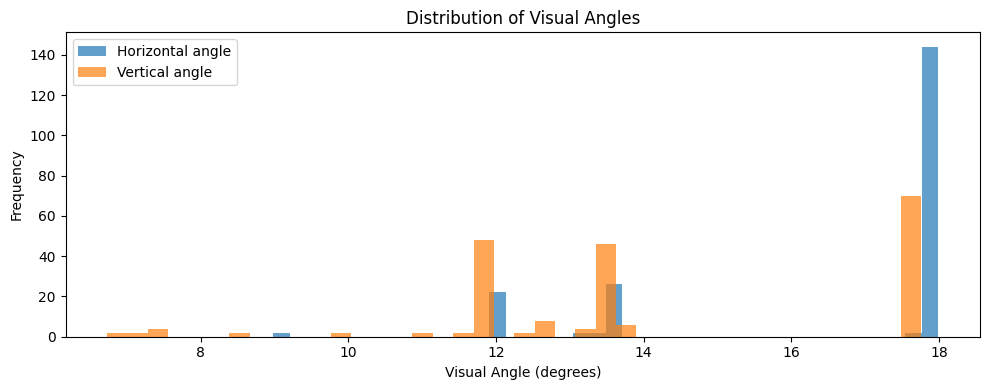

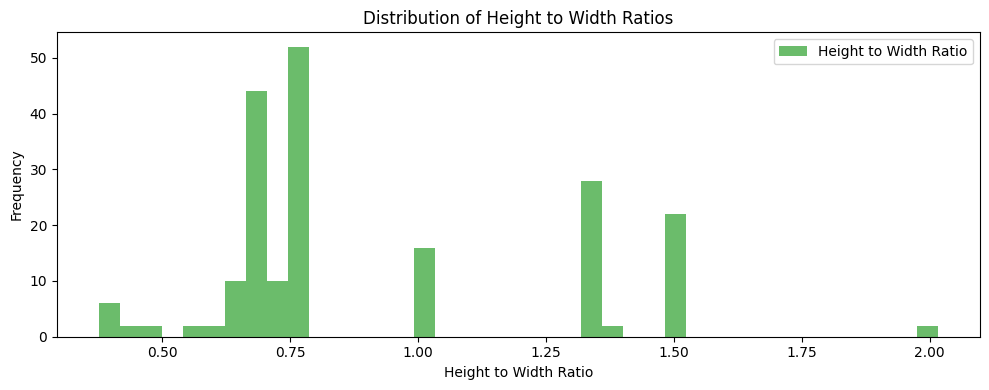

In [3]:
import math, os
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import csv, cv2, torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def compute_visual_angle(
    screen_width_px, screen_height_px,
    screen_width_cm, screen_height_cm,
    image_width_px, image_height_px,
    eye_distance_cm
):
    # Step 1: pixels per cm
    pixels_per_cm_x = screen_width_px / screen_width_cm
    pixels_per_cm_y = screen_height_px / screen_height_cm

    # Step 2: image size in cm
    image_width_cm = image_width_px / pixels_per_cm_x
    image_height_cm = image_height_px / pixels_per_cm_y

    # Step 3: visual angle in degrees
    theta_horizontal = 2 * math.degrees(math.atan((image_width_cm / 2) / eye_distance_cm))
    theta_vertical = 2 * math.degrees(math.atan((image_height_cm / 2) / eye_distance_cm))

    return theta_horizontal, theta_vertical

data_root = "/home/jinhanz/cs/concreteness/data"
imageinfo = pd.read_csv("/home/jinhanz/cs/concreteness/processing/stimuli_experiment/20250723_193742/image_info.csv")

# Example usage
screen_w_px = 1280
screen_h_px = 1024
screen_w_mm = 380
screen_h_mm = 300
eye_dist_mm = 690

horizontal_angle_all = []
vertical_angle_all = []
h_to_w_ratio_all = []

for row in imageinfo.itertuples():
    image_size = row.image_size
    img_w, img_h = [int(coord) for coord in image_size.strip('[]').split(',')]

    horizontal_angle, vertical_angle = compute_visual_angle(
        screen_w_px, screen_h_px,
        screen_w_mm, screen_h_mm,
        img_w, img_h,
        eye_dist_mm
    )

    horizontal_angle_all.append(horizontal_angle)
    vertical_angle_all.append(vertical_angle)
    h_to_w_ratio_all.append(img_h / img_w)

plt.figure(figsize=(10, 4))
plt.hist(horizontal_angle_all, bins=40, alpha=0.7, label='Horizontal angle')
plt.hist(vertical_angle_all, bins=40, alpha=0.7, label='Vertical angle')
plt.xlabel('Visual Angle (degrees)')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of Visual Angles')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(h_to_w_ratio_all, bins=40, alpha=0.7, color="tab:green", label='Height to Width Ratio')
plt.xlabel('Height to Width Ratio')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of Height to Width Ratios')
plt.tight_layout()
plt.show()

In [4]:
import numpy as np

# Calculate mean and standard deviation for horizontal and vertical angles
horizontal_mean = np.mean(horizontal_angle_all)
horizontal_std = np.std(horizontal_angle_all)

vertical_mean = np.mean(vertical_angle_all)
vertical_std = np.std(vertical_angle_all)

# Print the results
print(f"Horizontal Visual Angle: Mean = {horizontal_mean:.2f}, Std = {horizontal_std:.2f}")
print(f"Vertical Visual Angle: Mean = {vertical_mean:.2f}, Std = {vertical_std:.2f}")

Horizontal Visual Angle: Mean = 16.57, Std = 2.39
Vertical Visual Angle: Mean = 14.15, Std = 2.94
